# Análisis de descuentos - notebook ordenado y auditado

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patheffects as pe
from IPython.display import display

GRUPO_PRE_ANALISIS = "1. Cruces y filtros pre-análisis"
GRUPO_PRE_GRAFICOS = "4. Filtros pre-gráficos"

# ============================================================
# Bitácora de filtros y transformaciones
# ============================================================
bitacora_filtros = []


def _n_unicos(df, id_col=None):
    if id_col is None or id_col not in df.columns:
        return np.nan
    return df[id_col].nunique(dropna=True)


def _normalizar_mask(mask, df):
    if isinstance(mask, (bool, np.bool_)):
        return pd.Series(bool(mask), index=df.index)

    if isinstance(mask, pd.Series):
        mask = mask.reindex(df.index)
    else:
        mask = pd.Series(mask, index=df.index)

    return mask.fillna(False).astype(bool)


def limpiar_bitacora_filtros(grupo=None):
    global bitacora_filtros
    if grupo is None:
        bitacora_filtros = []
    else:
        bitacora_filtros = [
            registro
            for registro in bitacora_filtros
            if registro.get("grupo") != grupo
        ]
    return pd.DataFrame(bitacora_filtros)


def registrar_cambio(
    paso,
    df_antes,
    df_despues,
    grupo="",
    id_col=None,
    tipo="filtro",
    notas="",
):
    n_antes = len(df_antes)
    n_despues = len(df_despues)
    n_eliminadas = n_antes - n_despues
    pct_eliminado = n_eliminadas / n_antes if n_antes else 0

    ids_antes = _n_unicos(df_antes, id_col)
    ids_despues = _n_unicos(df_despues, id_col)

    registro = {
        "grupo": grupo,
        "tipo": tipo,
        "paso": paso,
        "filas_antes": n_antes,
        "filas_despues": n_despues,
        "filas_eliminadas": n_eliminadas,
        "pct_eliminado": pct_eliminado,
        "ids_antes": ids_antes,
        "ids_despues": ids_despues,
        "ids_eliminados": (
            ids_antes - ids_despues
            if pd.notna(ids_antes) and pd.notna(ids_despues)
            else np.nan
        ),
        "notas": notas,
    }
    bitacora_filtros.append(registro)

    etiqueta_grupo = f"{grupo} | " if grupo else ""
    print(
        f"{etiqueta_grupo}{paso}: "
        f"{n_antes:,} -> {n_despues:,} filas "
        f"({n_eliminadas:,} eliminadas; {pct_eliminado:.1%})"
    )
    if notas:
        print(f"  Nota: {notas}")

    return registro


def registrar_estado(paso, df, grupo="", id_col=None, notas=""):
    return registrar_cambio(
        paso=paso,
        df_antes=df,
        df_despues=df,
        grupo=grupo,
        id_col=id_col,
        tipo="estado",
        notas=notas,
    )


def registrar_transformacion(paso, df_antes, df_despues, grupo="", id_col=None, notas=""):
    return registrar_cambio(
        paso=paso,
        df_antes=df_antes,
        df_despues=df_despues,
        grupo=grupo,
        id_col=id_col,
        tipo="transformación",
        notas=notas,
    )


def aplicar_filtro(df, condicion, paso, grupo="", id_col=None, notas=""):
    mask = condicion(df) if callable(condicion) else condicion
    mask = _normalizar_mask(mask, df)
    df_despues = df.loc[mask].copy()

    registrar_cambio(
        paso=paso,
        df_antes=df,
        df_despues=df_despues,
        grupo=grupo,
        id_col=id_col,
        tipo="filtro",
        notas=notas,
    )
    return df_despues


def _desempaquetar_filtro(filtro):
    if isinstance(filtro, dict):
        return (
            filtro["paso"],
            filtro["condicion"],
            filtro.get("notas", ""),
        )

    if len(filtro) == 2:
        paso, condicion = filtro
        notas = ""
    else:
        paso, condicion, notas = filtro

    return paso, condicion, notas


def auditar_filtros_secuenciales(df, filtros, grupo="", id_col=None):
    actual = df.copy()
    registros = []

    for filtro in filtros:
        paso, condicion, notas = _desempaquetar_filtro(filtro)
        actual = aplicar_filtro(
            actual,
            condicion,
            paso=paso,
            grupo=grupo,
            id_col=id_col,
            notas=notas,
        )
        registros.append(bitacora_filtros[-1])

    return actual, pd.DataFrame(registros)


def calcular_impacto_individual(df, filtros, id_col=None):
    filas = []

    for filtro in filtros:
        paso, condicion, notas = _desempaquetar_filtro(filtro)
        mask = condicion(df) if callable(condicion) else condicion
        mask = _normalizar_mask(mask, df)
        df_despues = df.loc[mask].copy()

        ids_antes = _n_unicos(df, id_col)
        ids_despues = _n_unicos(df_despues, id_col)

        filas.append({
            "paso": paso,
            "filas_antes": len(df),
            "filas_despues": len(df_despues),
            "filas_eliminadas": len(df) - len(df_despues),
            "pct_eliminado": (len(df) - len(df_despues)) / len(df) if len(df) else 0,
            "ids_antes": ids_antes,
            "ids_despues": ids_despues,
            "ids_eliminados": (
                ids_antes - ids_despues
                if pd.notna(ids_antes) and pd.notna(ids_despues)
                else np.nan
            ),
            "notas": notas,
        })

    return pd.DataFrame(filas)


def mostrar_bitacora_filtros(grupo=None):
    tabla = pd.DataFrame(bitacora_filtros)

    if tabla.empty:
        print("La bitácora de filtros todavía está vacía.")
        return tabla

    if grupo is not None:
        tabla = tabla.loc[tabla["grupo"].eq(grupo)].copy()

    if tabla.empty:
        print(f"No hay registros para el grupo: {grupo}")
        return tabla

    tabla = tabla.copy()
    tabla["pct_eliminado"] = (tabla["pct_eliminado"] * 100).round(2)

    columnas = [
        "grupo",
        "tipo",
        "paso",
        "filas_antes",
        "filas_despues",
        "filas_eliminadas",
        "pct_eliminado",
        "ids_antes",
        "ids_despues",
        "ids_eliminados",
        "notas",
    ]
    columnas = [col for col in columnas if col in tabla.columns]

    display(tabla[columnas])
    return tabla[columnas]


# 0. Cargas de datos

## 0.1 Ventas

In [2]:
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas_raw = pd.read_csv(path_ventas)
print("Ventas crudas - Filas:", ventas_raw.shape[0])
display(ventas_raw.head())


/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_20402/1757549138.py:2: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas_raw = pd.read_csv(path_ventas)


Ventas crudas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
ventas_raw.columns


Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto'],
      dtype='str')

## 0.2 Maestro SKU

In [4]:
path_maestro = "datos/Maestro Productos.xlsx"
maestro_raw = pd.read_excel(path_maestro, header=2)
print("Maestro SKU - Filas:", maestro_raw.shape[0])
display(maestro_raw.head())


Maestro SKU - Filas: 1870


,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [5]:
maestro_raw.columns


Index(['Material', 'Texto breve de material', 'Material - COD SKU',
       'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
       'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
       'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
       'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
       'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
       'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
       'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
       'Descripción'],
      dtype='str')

# 1. Cruces y filtros pre-análisis

## 1.1 Bitácora de filtros y transformaciones

La bitácora registra filtros secuenciales y transformaciones sin cambiar la lógica del análisis. Se usa `venta_id` como identificador de trazabilidad.

## 1.2 Filtros auditados de ventas

In [6]:
limpiar_bitacora_filtros(GRUPO_PRE_ANALISIS)

canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
]

cols_relevantes_ventas = [
    "Cod Cliente",
    "Cod Canal Comercial",
    "Cod Consolidado",
    "Fecha Factura",
    "Cod SKU",
    "Nombre SKU",
    "Monto Real",
    "Kilo Real",
    "Precio",
    "venta_id",
    "Zona",
    "Distrito",
    "Precio_Lista",
    "dscto_base",
    "dscto_volumen",
    "dscto_binario",
    "carta_impacto",
    "id_descuento_base",
    "ids_descuento_volumen",
    "id_descuento_binario",
    "id_descuento_carta_impacto",
]

cols_nulos_permitidos = [
    "Zona",
    "Distrito",
    "dscto_base",
    "dscto_volumen",
    "dscto_binario",
    "carta_impacto",
    "id_descuento_base",
    "ids_descuento_volumen",
    "id_descuento_binario",
    "id_descuento_carta_impacto",
]
cols_obligatorias_ventas = [
    columna
    for columna in cols_relevantes_ventas
    if columna not in cols_nulos_permitidos
]

ventas = ventas_raw.copy()
registrar_estado(
    "Ventas crudas cargadas",
    ventas,
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas=f"Archivo fuente: {path_ventas}",
)

ventas = aplicar_filtro(
    ventas,
    ventas["Kilos Nc"].isna(),
    paso="Ventas: Kilos Nc nulo",
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas="Excluye notas de crédito o ajustes con kilos NC informados.",
)

ventas = aplicar_filtro(
    ventas,
    ventas["Nombre Consolidado"].isin(canales_relevantes),
    paso="Ventas: Nombre Consolidado en canales relevantes",
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas=f"Canales incluidos: {canales_relevantes}",
)

ventas = ventas[cols_relevantes_ventas].copy()

ventas = aplicar_filtro(
    ventas,
    lambda df: df[cols_obligatorias_ventas].notna().all(axis=1),
    paso="Ventas: columnas obligatorias completas",
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas=f"Se permiten nulos en: {cols_nulos_permitidos}",
)

ventas["Fecha Factura"] = pd.to_datetime(ventas["Fecha Factura"], errors="coerce")
ventas = aplicar_filtro(
    ventas,
    ventas["Fecha Factura"].notna(),
    paso="Ventas: fecha_factura válida",
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas="Convierte Fecha Factura a datetime y elimina fechas inválidas.",
)

ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial",
    "cod_consolidado",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "venta_id",
    "zona",
    "distrito",
    "precio_lista",
    "dscto_base",
    "dscto_volumen",
    "dscto_binario",
    "carta_impacto",
    "id_descuento_base",
    "ids_descuento_volumen",
    "id_descuento_binario",
    "id_descuento_carta_impacto",
]
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

print("Ventas auditadas - Filas:", ventas.shape[0])
display(ventas.head())


1. Cruces y filtros pre-análisis | Ventas crudas cargadas: 10,596,574 -> 10,596,574 filas (0 eliminadas; 0.0%)
  Nota: Archivo fuente: datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv
1. Cruces y filtros pre-análisis | Ventas: Kilos Nc nulo: 10,596,574 -> 9,853,682 filas (742,892 eliminadas; 7.0%)
  Nota: Excluye notas de crédito o ajustes con kilos NC informados.
1. Cruces y filtros pre-análisis | Ventas: Nombre Consolidado en canales relevantes: 9,853,682 -> 8,942,458 filas (911,224 eliminadas; 9.2%)
  Nota: Canales incluidos: ['COBERTURA', 'VOLUMEN COBERTURA']
1. Cruces y filtros pre-análisis | Ventas: columnas obligatorias completas: 8,942,458 -> 8,942,307 filas (151 eliminadas; 0.0%)
  Nota: Se permiten nulos en: ['Zona', 'Distrito', 'dscto_base', 'dscto_volumen', 'dscto_binario', 'carta_impacto', 'id_descuento_base', 'ids_descuento_volumen', 'id_descuento_binario', 'id_descuento_carta_impacto']
1. Cruces y filtros pre-análisis | Ventas: fecha_factura vá

,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,venta_id,...,dscto_base,dscto_volumen,dscto_binario,carta_impacto,id_descuento_base,ids_descuento_volumen,id_descuento_binario,id_descuento_carta_impacto,año_factura,mes_factura
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,1
3,1174760,CB,32,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,4525.833333,398,...,-12.5,NaN,NaN,NaN,2372.0,NaN,NaN,NaN,2025,1
7,1137411,CB,54,2025-01-02,6800,"PAPAS FRITAS 2,5 KG calibre 7x7 MAESTRO",213202,100.0,2132.020000,21875,...,-3.0,NaN,NaN,NaN,2837.0,NaN,NaN,NaN,2025,1
9,1134837,CB,32,2025-01-02,3145,PASTA SALAME 16x125 GR LP,9308,2.0,4654.000000,21518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,1
10,1114635,CB,54,2025-01-02,3144,PASTA POLLO PIMENTON 16x125 GR LP,9028,2.0,4514.000000,21240,...,-3.0,NaN,NaN,NaN,1277.0,NaN,NaN,NaN,2025,1


## 1.3 Cruce con maestro SKU y construcción de unidades

In [7]:
cols_relevantes_maestro = [
    "Material",
    "Texto breve de material",
    "Peso Var/Std",
    "Neto",
]

maestro = maestro_raw[cols_relevantes_maestro].copy()
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro = maestro.drop(columns=["Peso Var/Std"])
maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable",
]

ventas_antes_merge = ventas.copy()
ventas = ventas.merge(
    maestro[["cod_sku", "texto_breve_material", "kg_por_unidad", "peso_variable"]],
    on="cod_sku",
    how="left",
)
registrar_transformacion(
    "Ventas: merge con maestro SKU",
    ventas_antes_merge,
    ventas,
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas=(
        f"Filas sin kg_por_unidad: {ventas['kg_por_unidad'].isna().sum()}; "
        f"filas sin texto_breve_material: {ventas['texto_breve_material'].isna().sum()}"
    ),
)

ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas["cantidad_unidades_entera"] = (
    ventas["cantidad_unidades"].isna()
    | np.isclose(
        ventas["cantidad_unidades"],
        np.round(ventas["cantidad_unidades"]),
        atol=1e-6,
        rtol=0,
    )
)
ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (
    (ventas["peso_variable"] == False)
    & (ventas["cantidad_unidades_entera"] == False)
)
ventas["unidades_redondeadas"] = ventas["inconsistencia"].fillna(False)

ventas_antes_redondeo = ventas.copy()
n_inconsistencias = int(ventas["inconsistencia"].sum())
ventas["cantidad_unidades"] = np.where(
    ventas["inconsistencia"],
    np.round(ventas["cantidad_unidades"]),
    ventas["cantidad_unidades"],
)
registrar_transformacion(
    "Ventas: redondear cantidad_unidades inconsistente",
    ventas_antes_redondeo,
    ventas,
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas=f"Filas redondeadas: {n_inconsistencias}",
)

ventas = aplicar_filtro(
    ventas,
    ventas["cantidad_unidades"] > 0,
    paso="Ventas: cantidad_unidades > 0",
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas="Excluye ventas sin unidades positivas luego del cruce con maestro.",
)

display(ventas.head())


1. Cruces y filtros pre-análisis | Ventas: merge con maestro SKU: 8,942,307 -> 8,942,307 filas (0 eliminadas; 0.0%)
  Nota: Filas sin kg_por_unidad: 0; filas sin texto_breve_material: 0
1. Cruces y filtros pre-análisis | Ventas: redondear cantidad_unidades inconsistente: 8,942,307 -> 8,942,307 filas (0 eliminadas; 0.0%)
  Nota: Filas redondeadas: 231
1. Cruces y filtros pre-análisis | Ventas: cantidad_unidades > 0: 8,942,307 -> 8,942,112 filas (195 eliminadas; 0.0%)
  Nota: Excluye ventas sin unidades positivas luego del cruce con maestro.


,cod_cliente,cod_canal_comercial,cod_consolidado,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,venta_id,...,id_descuento_carta_impacto,año_factura,mes_factura,texto_breve_material,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,unidades_redondeadas
0,1145633,CB,32,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,0,...,NaN,2025,1,SALAME 10X100 GR LP,0.100,False,40.0,True,False,False
1,1174760,CB,32,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,4525.833333,398,...,NaN,2025,1,HAMBURGUESA GRILL TASTE LP 24X100 GR.,0.100,False,24.0,True,False,False
2,1137411,CB,54,2025-01-02,6800,"PAPAS FRITAS 2,5 KG calibre 7x7 MAESTRO",213202,100.0,2132.020000,21875,...,NaN,2025,1,"PAPAS FRITAS 2,5 KG CALIBRE 7X7 MAESTRO",2.500,False,40.0,True,False,False
3,1134837,CB,32,2025-01-02,3145,PASTA SALAME 16x125 GR LP,9308,2.0,4654.000000,21518,...,NaN,2025,1,PASTA SALAME 16X125 GR LP,0.125,False,16.0,True,False,False
4,1114635,CB,54,2025-01-02,3144,PASTA POLLO PIMENTON 16x125 GR LP,9028,2.0,4514.000000,21240,...,NaN,2025,1,PASTA POLLO PIMENTON 16X125 GR LP,0.125,False,16.0,True,False,False


In [8]:
mostrar_bitacora_filtros(GRUPO_PRE_ANALISIS)


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,1. Cruces y filtros pre-análisis,estado,Ventas crudas cargadas,10596574,10596574,0,0.00,10596574,10596574,0,Archivo fuente: datos/Ventas por Cliente/venta...
1,1. Cruces y filtros pre-análisis,filtro,Ventas: Kilos Nc nulo,10596574,9853682,742892,7.01,10596574,9853682,742892,Excluye notas de crédito o ajustes con kilos N...
2,1. Cruces y filtros pre-análisis,filtro,Ventas: Nombre Consolidado en canales relevantes,9853682,8942458,911224,9.25,9853682,8942458,911224,"Canales incluidos: ['COBERTURA', 'VOLUMEN COBE..."
3,1. Cruces y filtros pre-análisis,filtro,Ventas: columnas obligatorias completas,8942458,8942307,151,0.00,8942458,8942307,151,"Se permiten nulos en: ['Zona', 'Distrito', 'ds..."
4,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura válida,8942307,8942307,0,0.00,8942307,8942307,0,Convierte Fecha Factura a datetime y elimina f...
5,1. Cruces y filtros pre-análisis,transformación,Ventas: merge con maestro SKU,8942307,8942307,0,0.00,8942307,8942307,0,Filas sin kg_por_unidad: 0; filas sin texto_br...
6,1. Cruces y filtros pre-análisis,transformación,Ventas: redondear cantidad_unidades inconsistente,8942307,8942307,0,0.00,8942307,8942307,0,Filas redondeadas: 231
7,1. Cruces y filtros pre-análisis,filtro,Ventas: cantidad_unidades > 0,8942307,8942112,195,0.00,8942307,8942112,195,Excluye ventas sin unidades positivas luego de...


,grupo,tipo,paso,filas_antes,filas_despues,filas_eliminadas,pct_eliminado,ids_antes,ids_despues,ids_eliminados,notas
0,1. Cruces y filtros pre-análisis,estado,Ventas crudas cargadas,10596574,10596574,0,0.00,10596574,10596574,0,Archivo fuente: datos/Ventas por Cliente/venta...
1,1. Cruces y filtros pre-análisis,filtro,Ventas: Kilos Nc nulo,10596574,9853682,742892,7.01,10596574,9853682,742892,Excluye notas de crédito o ajustes con kilos N...
2,1. Cruces y filtros pre-análisis,filtro,Ventas: Nombre Consolidado en canales relevantes,9853682,8942458,911224,9.25,9853682,8942458,911224,"Canales incluidos: ['COBERTURA', 'VOLUMEN COBE..."
3,1. Cruces y filtros pre-análisis,filtro,Ventas: columnas obligatorias completas,8942458,8942307,151,0.00,8942458,8942307,151,"Se permiten nulos en: ['Zona', 'Distrito', 'ds..."
4,1. Cruces y filtros pre-análisis,filtro,Ventas: fecha_factura válida,8942307,8942307,0,0.00,8942307,8942307,0,Convierte Fecha Factura a datetime y elimina f...
5,1. Cruces y filtros pre-análisis,transformación,Ventas: merge con maestro SKU,8942307,8942307,0,0.00,8942307,8942307,0,Filas sin kg_por_unidad: 0; filas sin texto_br...
6,1. Cruces y filtros pre-análisis,transformación,Ventas: redondear cantidad_unidades inconsistente,8942307,8942307,0,0.00,8942307,8942307,0,Filas redondeadas: 231
7,1. Cruces y filtros pre-análisis,filtro,Ventas: cantidad_unidades > 0,8942307,8942112,195,0.00,8942307,8942112,195,Excluye ventas sin unidades positivas luego de...


# 2. Construcción de variables de análisis

## 2.1 Precio por unidad y descuento observado

In [9]:
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

display(ventas[[
    "venta_id",
    "cod_sku",
    "precio_por_unidad",
    "precio_lista_por_unidad",
    "cantidad_unidades",
]].head())


,venta_id,cod_sku,precio_por_unidad,precio_lista_por_unidad,cantidad_unidades
0,0,3034,1086.000000,1153.80,40.0
1,398,3991,452.583333,517.10,24.0
2,21875,6800,5330.050000,5495.00,40.0
3,21518,3145,581.750000,581.75,16.0
4,21240,3144,564.250000,581.75,16.0


## 2.2 Matching de descuento aplicado

In [10]:
# Agregar columna de descuento aplicado.
# Se considera que una venta calza con un descuento si el descuento porcentual observado
# queda dentro de una tolerancia chica respecto a uno de los descuentos disponibles.
# Prioridad global: carta_impacto -> base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.
# Entre descuentos porcentuales se elige el de menor diferencia absoluta; ante empate,
# la comparación estricta diff < mejor_diff preserva el orden base -> volumen_1 -> volumen_2 -> volumen_3 -> binario.

tolerancia_pct = 1
eps_descuento = 1e-9
tolerancia_precio_carta = 1.0
labels_descuento = np.array([
    "ninguno",
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
], dtype=object)

# Descuento porcentual observado a nivel de precio por unidad.
descuento_pct_observado = ((ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) - 1.0).to_numpy(dtype=np.float32) * np.float32(100.0)

# Se guarda sólo el mejor match para no materializar matrices grandes en memoria.
mejor_diff = np.full(len(ventas), np.inf, dtype=np.float32)
codigos_descuento = np.zeros(len(ventas), dtype=np.int8)
descuento_pct_matcheado = np.zeros(len(ventas), dtype=np.float32)
id_descuento_aplicado = np.full(len(ventas), np.nan, dtype=np.float64)

def _actualizar_mejor_match(candidatos, codigo, ids_candidatos=None):
    candidatos = pd.to_numeric(candidatos, errors="coerce").to_numpy(dtype=np.float32)
    validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
    if not validos.any():
        return

    diff = np.abs(descuento_pct_observado - candidatos)
    mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff)
    mejor_diff[mask] = diff[mask]
    codigos_descuento[mask] = codigo
    descuento_pct_matcheado[mask] = candidatos[mask]
    if ids_candidatos is not None:
        ids_candidatos = pd.to_numeric(ids_candidatos, errors="coerce").to_numpy(dtype=np.float64)
        id_descuento_aplicado[mask] = ids_candidatos[mask]

_actualizar_mejor_match(ventas["dscto_base"], 1, ventas["id_descuento_base"])

# dscto_volumen viene serializado como string tipo "[-5.0, -10.0]" en el CSV final.
# ids_descuento_volumen viene serializado como string tipo "[12, 25]" y sigue el mismo orden.
mask_volumen = ventas["dscto_volumen"].notna() & ventas["ids_descuento_volumen"].notna()
if mask_volumen.any():
    volumen_extraido = ventas.loc[mask_volumen, "dscto_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    ids_volumen_extraidos = ventas.loc[mask_volumen, "ids_descuento_volumen"].astype("string").str.extract(
        r"\[\s*([-\d\.]+)?(?:,\s*([-\d\.]+))?(?:,\s*([-\d\.]+))?\s*\]"
    )
    idx_volumen = np.flatnonzero(mask_volumen.to_numpy())

    for codigo, col in enumerate(volumen_extraido.columns, start=2):
        candidatos = pd.to_numeric(volumen_extraido[col], errors="coerce").to_numpy(dtype=np.float32)
        ids_candidatos = pd.to_numeric(ids_volumen_extraidos[col], errors="coerce").to_numpy(dtype=np.float64)
        validos = (~np.isnan(candidatos)) & (np.abs(candidatos) > eps_descuento)
        if not validos.any():
            continue

        diff = np.abs(descuento_pct_observado[idx_volumen] - candidatos)
        mejor_diff_local = mejor_diff[idx_volumen]
        mask = validos & (diff <= tolerancia_pct) & (diff < mejor_diff_local)
        if mask.any():
            idx_target = idx_volumen[mask]
            mejor_diff[idx_target] = diff[mask]
            codigos_descuento[idx_target] = codigo
            descuento_pct_matcheado[idx_target] = candidatos[mask]
            id_descuento_aplicado[idx_target] = ids_candidatos[mask]

_actualizar_mejor_match(ventas["dscto_binario"], 5, ventas["id_descuento_binario"])

# carta_impacto representa un precio objetivo, no un descuento porcentual, y si calza por precio_real
# dentro de la tolerancia definida, pisa cualquier match porcentual previo.
precio_real_array = pd.to_numeric(ventas["precio_real"], errors="coerce").to_numpy(dtype=np.float32)
precio_lista_array = pd.to_numeric(ventas["precio_lista"], errors="coerce").to_numpy(dtype=np.float32)
carta_array = pd.to_numeric(ventas["carta_impacto"], errors="coerce").to_numpy(dtype=np.float32)
carta_ids_array = pd.to_numeric(ventas["id_descuento_carta_impacto"], errors="coerce").to_numpy(dtype=np.float64)
carta_pct_equivalente = np.where(
    (~np.isnan(carta_array)) & (~np.isnan(precio_lista_array)) & (np.abs(precio_lista_array) > eps_descuento),
    ((carta_array / precio_lista_array) - np.float32(1.0)) * np.float32(100.0),
    np.nan,
)
mask_carta = (~np.isnan(carta_array)) & (np.abs(precio_real_array - carta_array) <= tolerancia_precio_carta)
codigos_descuento[mask_carta] = 6
descuento_pct_matcheado[mask_carta] = carta_pct_equivalente[mask_carta]
mejor_diff[mask_carta] = np.abs(descuento_pct_observado[mask_carta] - descuento_pct_matcheado[mask_carta])
id_descuento_aplicado[mask_carta] = carta_ids_array[mask_carta]

ventas["descuento_pct_observado"] = descuento_pct_observado
ventas["descuento_pct_matcheado"] = descuento_pct_matcheado
ventas["diferencia_descuento_pct"] = ventas["descuento_pct_observado"] - ventas["descuento_pct_matcheado"]
ventas["descuento_aplicado"] = pd.Categorical.from_codes(codigos_descuento, categories=labels_descuento)
ventas["id_descuento_aplicado"] = pd.array(id_descuento_aplicado, dtype="Int64")
ventas["calza_con_descuento"] = np.not_equal(codigos_descuento, 0)

print("Distribución descuento_aplicado:")
print(ventas["descuento_aplicado"].value_counts(dropna=False))
print(f"Cobertura de match: {ventas['calza_con_descuento'].mean():.2%}")

cols_muestra = [
    "cod_sku",
    "cod_canal_comercial",
    "cod_consolidado",
    "fecha_factura",
    "precio_por_unidad",
    "precio_lista_por_unidad",
    "descuento_pct_observado",
    "dscto_base",
    "id_descuento_base",
    "dscto_volumen",
    "ids_descuento_volumen",
    "dscto_binario",
    "id_descuento_binario",
    "carta_impacto",
    "id_descuento_carta_impacto",
    "descuento_pct_matcheado",
    "diferencia_descuento_pct",
    "descuento_aplicado",
    "id_descuento_aplicado",
]
ventas.loc[ventas["calza_con_descuento"], cols_muestra].head()

Distribución descuento_aplicado:
descuento_aplicado
ninguno          6862238
binario          1103916
base              658331
volumen_1         208611
volumen_2          78208
volumen_3          28850
carta_impacto       1958
Name: count, dtype: int64
Cobertura de match: 23.26%


,cod_sku,cod_canal_comercial,cod_consolidado,fecha_factura,precio_por_unidad,precio_lista_por_unidad,descuento_pct_observado,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado
1,3991,CB,32,2025-01-02,452.583333,517.10,-12.476633,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN,-12.5,0.023367,base,2372
2,6800,CB,54,2025-01-02,5330.050000,5495.00,-3.001820,-3.0,2837.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.001820,base,2837
4,3144,CB,54,2025-01-02,564.250000,581.75,-3.008165,-3.0,1277.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.008165,base,1277
5,3142,CB,54,2025-01-02,564.250000,581.75,-3.008165,-3.0,1262.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.008165,base,1262
6,8210,CB,54,2025-01-02,27650.653234,28506.24,-3.001402,-3.0,3077.0,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,-0.001402,base,3077


## 2.3 Gap, reclasificaciones y costo del descuento

In [11]:
ventas["gap"] = ventas["diferencia_descuento_pct"].abs() > 1
ventas["monto_a_precio_lista"] = ventas["precio_lista"] * ventas["kilo_real"]
ventas["costo_descuento"] = ventas["monto_a_precio_lista"] - ventas["monto_real"]

mask_base_forzado = (
    (ventas["gap"] == True)
    & (ventas["descuento_pct_observado"].round().isin([-3.0, -6.0]))
)
mask_liq_forzado = (
    (ventas["gap"] == True)
    & (ventas["descuento_pct_observado"].round().le(-40.0))
)

ventas_antes_reclasificacion = ventas.copy()
categorias_nuevas = [
    categoria
    for categoria in ["base_forzado", "liquidacion_forzado"]
    if categoria not in ventas["descuento_aplicado"].cat.categories
]
if categorias_nuevas:
    ventas["descuento_aplicado"] = ventas["descuento_aplicado"].cat.add_categories(categorias_nuevas)

ventas.loc[mask_base_forzado, "descuento_aplicado"] = "base_forzado"
ventas.loc[mask_liq_forzado, "descuento_aplicado"] = "liquidacion_forzado"
ventas.loc[mask_base_forzado | mask_liq_forzado, "id_descuento_aplicado"] = pd.NA

registrar_transformacion(
    "Ventas: reclasificaciones forzadas de descuento",
    ventas_antes_reclasificacion,
    ventas,
    grupo=GRUPO_PRE_ANALISIS,
    id_col="venta_id",
    notas=(
        f"base_forzado: {int(mask_base_forzado.sum())}; "
        f"liquidacion_forzado: {int(mask_liq_forzado.sum())}"
    ),
)

display(ventas[[
    "venta_id",
    "descuento_pct_observado",
    "descuento_pct_matcheado",
    "diferencia_descuento_pct",
    "descuento_aplicado",
    "gap",
    "costo_descuento",
]].head())


1. Cruces y filtros pre-análisis | Ventas: reclasificaciones forzadas de descuento: 8,942,112 -> 8,942,112 filas (0 eliminadas; 0.0%)
  Nota: base_forzado: 547027; liquidacion_forzado: 25598


,venta_id,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,gap,costo_descuento
0,0,-5.876235,0.0,-5.876235,base_forzado,True,2712.0
1,398,-12.476633,-12.5,0.023367,base,False,1548.4
2,21875,-3.001820,-3.0,-0.001820,base,False,6598.0
3,21518,0.000000,0.0,0.000000,ninguno,False,0.0
4,21240,-3.008165,-3.0,-0.008165,base,False,280.0


## 2.4 Export y chequeos rápidos

In [12]:
path_ventas_export = "datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv"
ventas.to_csv(path_ventas_export, index=False)
print(f"Base analítica exportada a: {path_ventas_export}")

print("Distribución de gap:")
display(ventas["gap"].value_counts(dropna=False))

ventas_no_gap = ventas.loc[ventas["gap"] == False].copy()
print("Distribución de descuento_aplicado para ventas sin gap:")
display(ventas_no_gap["descuento_aplicado"].value_counts(dropna=False))

print("Filas reclasificadas manualmente:")
display(pd.Series({
    "base_forzado": int(mask_base_forzado.sum()),
    "liquidacion_forzado": int(mask_liq_forzado.sum()),
}, name="filas"))


Base analítica exportada a: datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv
Distribución de gap:


gap
False    8281585
True      660527
Name: count, dtype: int64

Distribución de descuento_aplicado para ventas sin gap:


descuento_aplicado
ninguno                6201711
binario                1103916
base                    658331
volumen_1               208611
volumen_2                78208
volumen_3                28850
carta_impacto             1958
base_forzado                 0
liquidacion_forzado          0
Name: count, dtype: int64

Filas reclasificadas manualmente:


base_forzado           547027
liquidacion_forzado     25598
Name: filas, dtype: int64

# 3. Análisis exploratorio / ejemplo

## 3.1 Resumen agregado por tipo de descuento

In [13]:
tabla_descuentos = (
    ventas.groupby("descuento_aplicado", observed=False)
    .agg(
        monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
        monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
        costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum"),
    )
    .reset_index()
)

display(tabla_descuentos)


,descuento_aplicado,monto_a_precio_lista,monto_total_vendido,costo_total_descuento
0,ninguno,9.559643e+10,95351268872,2.451639e+08
1,base,1.769806e+10,16993267288,7.047934e+08
2,volumen_1,5.299918e+09,4764393616,5.355246e+08
3,volumen_2,3.198406e+09,2719088965,4.793168e+08
4,volumen_3,1.791030e+09,1432703593,3.583267e+08
5,binario,2.206781e+10,19163604939,2.904207e+09
6,carta_impacto,1.167955e+08,106158511,1.063696e+07
7,base_forzado,1.140385e+10,11059532418,3.443173e+08
8,liquidacion_forzado,8.327069e+08,382507970,4.501990e+08


## 3.2 Corte 2026 T1 sin clientes excluidos

In [14]:
clientes_excluir_2026_trim1 = [1070919, 52847, 1227734, 1233882, 1218124]

ventas_2026_trim1_sin_clientes = ventas[
    (ventas["año_factura"] == 2026)
    & (ventas["mes_factura"].isin([1, 2, 3]))
    & (~ventas["cod_cliente"].isin(clientes_excluir_2026_trim1))
].copy()

tabla_descuentos_2026_trim1_sin_clientes = (
    ventas_2026_trim1_sin_clientes.groupby("descuento_aplicado", observed=False)
    .agg(
        monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
        monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
        costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum"),
    )
    .reset_index()
)


In [15]:
display(tabla_descuentos_2026_trim1_sin_clientes)


,descuento_aplicado,monto_a_precio_lista,monto_total_vendido,costo_total_descuento
0,ninguno,1.780454e+10,17635702968,1.688348e+08
1,base,2.392691e+09,2301736267,9.095485e+07
2,volumen_1,3.176543e+09,2845039769,3.315029e+08
3,volumen_2,1.820227e+09,1540561522,2.796660e+08
4,volumen_3,1.366092e+09,1090664200,2.754280e+08
5,binario,6.036751e+09,5171036007,8.657149e+08
6,carta_impacto,0.000000e+00,0,0.000000e+00
7,base_forzado,1.040463e+09,1008864714,3.159847e+07
8,liquidacion_forzado,1.967479e+08,88342373,1.084055e+08


# 4. Filtros pre-gráficos

## 4.1 Base para gráficos y helpers de filtrado

In [16]:
CATEGORIAS_DESCUENTO_DEFAULT = [
    "base",
    "volumen_1",
    "volumen_2",
    "volumen_3",
    "binario",
    "carta_impacto",
    "base_forzado",
    "liquidacion_forzado",
]

LABELS_DESCUENTO_DEFAULT = {
    "base": "Descuento Base",
    "volumen_1": "Descuento Volumen 1",
    "volumen_2": "Descuento Volumen 2",
    "volumen_3": "Descuento Volumen 3",
    "binario": "Descuento Binario",
    "carta_impacto": "Carta Impacto",
    "base_forzado": "Base Forzado",
    "liquidacion_forzado": "Liquidación Forzado",
}


def _normalizar_valores_filtro(valores):
    if valores is None:
        return None
    if isinstance(valores, (str, bytes)):
        return [valores]
    if np.isscalar(valores):
        return [valores]
    return list(valores)


def construir_filtros_grafico(
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    distritos=None,
    zonales=None,
):
    distritos = distritos if distritos is not None else zonales
    filtros = []

    filtros_inclusivos = [
        ("año_factura", _normalizar_valores_filtro(anios), "Años incluidos"),
        ("mes_factura", _normalizar_valores_filtro(meses), "Meses incluidos"),
        ("cod_canal_comercial", _normalizar_valores_filtro(canales), "Canales incluidos"),
        ("cod_sku", _normalizar_valores_filtro(skus), "SKUs incluidos"),
        ("cod_cliente", _normalizar_valores_filtro(clientes), "Clientes incluidos"),
        ("zona", _normalizar_valores_filtro(zonas), "Zonas incluidas"),
        ("distrito", _normalizar_valores_filtro(distritos), "Distritos incluidos"),
    ]

    for columna, valores, etiqueta in filtros_inclusivos:
        if valores is None:
            continue
        valores = list(valores)
        filtros.append({
            "paso": f"{columna} en selección",
            "condicion": (
                lambda df, columna=columna, valores=tuple(valores):
                df[columna].isin(valores) if columna in df.columns else pd.Series(True, index=df.index)
            ),
            "notas": f"{etiqueta}: {valores}",
        })

    clientes_excluir = _normalizar_valores_filtro(clientes_excluir)
    if clientes_excluir is not None:
        clientes_excluir = list(clientes_excluir)
        filtros.append({
            "paso": "Excluir clientes indicados",
            "condicion": (
                lambda df, valores=tuple(clientes_excluir):
                ~df["cod_cliente"].isin(valores) if "cod_cliente" in df.columns else pd.Series(True, index=df.index)
            ),
            "notas": f"Clientes excluidos: {clientes_excluir}",
        })

    return filtros


def _aplicar_filtros_silenciosos(df, filtros):
    filtrado = df
    for filtro in filtros:
        paso, condicion, _ = _desempaquetar_filtro(filtro)
        mask = condicion(filtrado) if callable(condicion) else condicion
        mask = _normalizar_mask(mask, filtrado)
        filtrado = filtrado.loc[mask].copy()
    return filtrado


def filtrar_ventas_grafico(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    distritos=None,
    zonales=None,
):
    filtros = construir_filtros_grafico(
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        clientes=clientes,
        clientes_excluir=clientes_excluir,
        zonas=zonas,
        distritos=distritos,
        zonales=zonales,
    )
    return _aplicar_filtros_silenciosos(df, filtros).copy()


def auditar_filtros_grafico(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    distritos=None,
    zonales=None,
    grupo=GRUPO_PRE_GRAFICOS,
    id_col="venta_id",
):
    filtros = construir_filtros_grafico(
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        clientes=clientes,
        clientes_excluir=clientes_excluir,
        zonas=zonas,
        distritos=distritos,
        zonales=zonales,
    )

    limpiar_bitacora_filtros(grupo)
    registrar_estado(
        "Base inicial para gráficos",
        df,
        grupo=grupo,
        id_col=id_col,
        notas=f"Filtros activos: {len(filtros)}",
    )

    if not filtros:
        columnas = [
            "paso",
            "filas_antes",
            "filas_despues",
            "filas_eliminadas",
            "pct_eliminado",
            "ids_antes",
            "ids_despues",
            "ids_eliminados",
            "notas",
        ]
        return df.copy(), pd.DataFrame(columns=columnas), pd.DataFrame(columns=columnas)

    impacto_individual = calcular_impacto_individual(df, filtros, id_col=id_col)
    filtrado, bitacora = auditar_filtros_secuenciales(
        df,
        filtros,
        grupo=grupo,
        id_col=id_col,
    )
    return filtrado.copy(), impacto_individual, bitacora


def armar_tabla_descuentos(df, unir_base_forzado=False):
    columnas = ["descuento_aplicado", "monto_a_precio_lista", "monto_real", "costo_descuento"]
    base = df[columnas].copy()
    base["descuento_aplicado"] = base["descuento_aplicado"].astype("object")

    if unir_base_forzado:
        base["descuento_aplicado"] = base["descuento_aplicado"].replace({"base_forzado": "base"})

    tabla = (
        base.groupby("descuento_aplicado", dropna=False, observed=False)
        .agg(
            monto_a_precio_lista=pd.NamedAgg(column="monto_a_precio_lista", aggfunc="sum"),
            monto_total_vendido=pd.NamedAgg(column="monto_real", aggfunc="sum"),
            costo_total_descuento=pd.NamedAgg(column="costo_descuento", aggfunc="sum"),
        )
        .reset_index()
    )
    return tabla


def _resolver_categorias_descuento(categorias=None, labels=None, unir_base_forzado=False):
    categorias_resueltas = list(categorias) if categorias is not None else CATEGORIAS_DESCUENTO_DEFAULT.copy()
    if unir_base_forzado:
        categorias_resueltas = [categoria for categoria in categorias_resueltas if categoria != "base_forzado"]

    labels_resueltos = LABELS_DESCUENTO_DEFAULT.copy()
    if labels is not None:
        labels_resueltos.update(labels)

    return categorias_resueltas, labels_resueltos


def _crear_ax(ax=None, figsize=(12, 6)):
    if ax is not None:
        return ax
    _, ax = plt.subplots(figsize=figsize)
    return ax


def _mostrar_sin_datos(ax, titulo, mensaje="Sin datos para los filtros seleccionados"):
    ax.clear()
    ax.text(0.5, 0.5, mensaje, ha="center", va="center", transform=ax.transAxes)
    ax.set_title(titulo)
    ax.set_axis_off()
    return ax


def _ylabel_desde_escala(escala):
    if escala == 1e9:
        return "Monto (miles de millones)"
    if escala == 1e6:
        return "Monto (millones)"
    return f"Monto / {escala:g}"


def _armar_waterfall_df(df, categorias=None, labels=None, unir_base_forzado=False, escala=1e9):
    categorias_resueltas, labels_resueltos = _resolver_categorias_descuento(
        categorias=categorias,
        labels=labels,
        unir_base_forzado=unir_base_forzado,
    )
    tabla_descuentos = armar_tabla_descuentos(df, unir_base_forzado=unir_base_forzado)

    costos_explicados = (
        tabla_descuentos
        .set_index("descuento_aplicado")["costo_total_descuento"]
        .reindex(categorias_resueltas, fill_value=0.0)
    )

    monto_a_precio_lista_total = df["monto_a_precio_lista"].sum()
    monto_real_total = df["monto_real"].sum()
    gap_total = monto_a_precio_lista_total - monto_real_total
    descuentos_explicados_total = costos_explicados.sum()
    gap_no_explicado = gap_total - descuentos_explicados_total

    pasos = [("Monto a Precio Lista", monto_a_precio_lista_total, "total")]
    pasos.extend(
        (labels_resueltos.get(categoria, categoria), -costos_explicados[categoria], "change")
        for categoria in categorias_resueltas
    )
    pasos.append(("Gap No Explicado", -gap_no_explicado, "change"))
    pasos.append(("Monto Real", monto_real_total, "total"))

    waterfall_df = pd.DataFrame(pasos, columns=["etapa", "valor", "tipo"])
    waterfall_df["running_after"] = np.nan
    waterfall_df["bottom"] = 0.0
    waterfall_df["height"] = 0.0

    running = 0.0
    for idx, row in waterfall_df.iterrows():
        valor = row["valor"]
        if row["tipo"] == "total":
            waterfall_df.at[idx, "bottom"] = 0.0
            waterfall_df.at[idx, "height"] = valor
            running = valor
        else:
            siguiente = running + valor
            waterfall_df.at[idx, "bottom"] = min(running, siguiente)
            waterfall_df.at[idx, "height"] = abs(valor)
            running = siguiente
        waterfall_df.at[idx, "running_after"] = running

    waterfall_df["bottom_plot"] = waterfall_df["bottom"] / escala
    waterfall_df["height_plot"] = waterfall_df["height"] / escala
    waterfall_df["valor_plot"] = waterfall_df["valor"] / escala
    waterfall_df["running_plot"] = waterfall_df["running_after"] / escala
    waterfall_df["top_plot"] = waterfall_df["bottom_plot"] + waterfall_df["height_plot"]

    return waterfall_df


def _add_break_marker(ax, patch, y_break, dx=0.10, dy=0.30, gap=0.10, lw=1.7):
    centro_x = patch.get_x() + patch.get_width() / 2
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [centro_x + shift - dx / 2, centro_x + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=8,
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal(),
        ])


def _add_axis_break(ax, y_break, x_offset=-0.58, dx=0.08, dy=0.30, gap=0.09, lw=1.7):
    for shift in (-gap / 2, gap / 2):
        line, = ax.plot(
            [x_offset + shift - dx / 2, x_offset + shift + dx / 2],
            [y_break - dy / 2, y_break + dy / 2],
            color="black",
            lw=lw,
            solid_capstyle="round",
            clip_on=False,
            zorder=9,
        )
        line.set_path_effects([
            pe.Stroke(linewidth=lw + 2.0, foreground="white"),
            pe.Normal(),
        ])


def graficar_barras_descuentos(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    distritos=None,
    zonales=None,
    categorias=None,
    unir_base_forzado=False,
    incluir_precio_lista=False,
    incluir_monto_real=False,
    titulo="Análisis de Descuentos",
    ax=None,
):
    ventas_filtradas = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        clientes=clientes,
        clientes_excluir=clientes_excluir,
        zonas=zonas,
        distritos=distritos,
        zonales=zonales,
    )
    ax = _crear_ax(ax=ax, figsize=(10, 6))

    if ventas_filtradas.empty:
        return _mostrar_sin_datos(ax, titulo)

    categorias_resueltas, labels_resueltos = _resolver_categorias_descuento(
        categorias=categorias,
        unir_base_forzado=unir_base_forzado,
    )
    tabla_descuentos = armar_tabla_descuentos(ventas_filtradas, unir_base_forzado=unir_base_forzado)
    costos = (
        tabla_descuentos
        .set_index("descuento_aplicado")["costo_total_descuento"]
        .reindex(categorias_resueltas, fill_value=0.0)
    )

    conceptos = []
    montos = []
    colores = []

    if incluir_precio_lista:
        conceptos.append("Monto a Precio Lista")
        montos.append(ventas_filtradas["monto_a_precio_lista"].sum())
        colores.append("#1f77b4")

    for categoria in categorias_resueltas:
        conceptos.append(labels_resueltos.get(categoria, categoria))
        montos.append(costos[categoria])
        colores.append("#ff7f0e")

    if incluir_monto_real:
        conceptos.append("Monto Real")
        montos.append(ventas_filtradas["monto_real"].sum())
        colores.append("#2ca02c")

    ax.bar(conceptos, montos, color=colores)
    ax.set_title(titulo)
    ax.set_ylabel("Monto")
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.figure.tight_layout()
    return ax


def graficar_waterfall_descuentos(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    distritos=None,
    zonales=None,
    categorias=None,
    labels=None,
    unir_base_forzado=False,
    y_floor=None,
    escala=1e9,
    titulo="Descomposición de descuentos desde Precio Lista hasta Monto Real",
    ax=None,
):
    ventas_filtradas = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        clientes=clientes,
        clientes_excluir=clientes_excluir,
        zonas=zonas,
        distritos=distritos,
        zonales=zonales,
    )
    ax = _crear_ax(ax=ax, figsize=(14, 7))

    if ventas_filtradas.empty:
        return _mostrar_sin_datos(ax, titulo)

    waterfall_df = _armar_waterfall_df(
        ventas_filtradas,
        categorias=categorias,
        labels=labels,
        unir_base_forzado=unir_base_forzado,
        escala=escala,
    )

    colores = []
    for _, row in waterfall_df.iterrows():
        if row["tipo"] == "total":
            colores.append("#1f77b4" if row["etapa"] == "Monto a Precio Lista" else "#2ca02c")
        elif row["etapa"] == "Gap No Explicado":
            colores.append("#d62728" if row["valor"] < 0 else "#ff9896")
        else:
            colores.append("#ff7f0e")

    x = np.arange(len(waterfall_df))
    bar_width = 0.8
    bars = ax.bar(
        x,
        waterfall_df["height_plot"],
        bottom=waterfall_df["bottom_plot"],
        width=bar_width,
        color=colores,
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )

    for idx in range(len(waterfall_df) - 1):
        y = waterfall_df.loc[idx, "running_plot"]
        ax.plot(
            [x[idx] + bar_width / 2, x[idx + 1] - bar_width / 2],
            [y, y],
            color="#666666",
            linestyle="--",
            linewidth=1,
            zorder=2,
        )

    offset_base = max(waterfall_df["height_plot"].max() * 0.02, 0.05)
    for idx, row in waterfall_df.iterrows():
        if row["tipo"] == "total":
            y_text = row["height_plot"]
            va = "bottom"
            offset = offset_base
        else:
            y_text = row["running_plot"]
            va = "bottom" if row["valor"] >= 0 else "top"
            offset = offset_base if row["valor"] >= 0 else -offset_base
        ax.text(
            x[idx],
            y_text + offset,
            f"{row['valor_plot']:+.2f}",
            ha="center",
            va=va,
            fontsize=9,
        )

    if y_floor is not None:
        visible_top = max(waterfall_df["top_plot"].max(), waterfall_df["running_plot"].max())
        if visible_top > y_floor:
            ax.set_ylim(y_floor, visible_top * 1.05)
            for patch, row in zip(bars, waterfall_df.itertuples(index=False)):
                if row.bottom_plot < y_floor < row.top_plot:
                    _add_break_marker(ax, patch, y_floor)
            _add_axis_break(ax, y_floor)

    ax.set_xticks(x)
    ax.set_xticklabels(waterfall_df["etapa"], rotation=35, ha="right")
    ax.set_ylabel(_ylabel_desde_escala(escala))
    ax.set_title(titulo)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.figure.tight_layout()
    return ax


In [17]:
ventas_base_graficos = ventas.copy()
ventas_graficos = ventas_base_graficos.copy()
print("Base disponible para gráficos:", ventas_base_graficos.shape)


Base disponible para gráficos: (8942112, 41)


## 4.2 Filtros editables y auditoría secuencial

In [18]:
ANIOS_GRAFICOS = None
MESES_GRAFICOS = None
CANALES_GRAFICOS = None
SKUS_GRAFICOS = None
CLIENTES_GRAFICOS = None
CLIENTES_EXCLUIR_GRAFICOS = None
ZONAS_GRAFICAS = None
DISTRITOS_GRAFICOS = None

filtros_graficos_kwargs = {
    "anios": ANIOS_GRAFICOS,
    "meses": MESES_GRAFICOS,
    "canales": CANALES_GRAFICOS,
    "skus": SKUS_GRAFICOS,
    "clientes": CLIENTES_GRAFICOS,
    "clientes_excluir": CLIENTES_EXCLUIR_GRAFICOS,
    "zonas": ZONAS_GRAFICAS,
    "distritos": DISTRITOS_GRAFICOS,
}

ventas_graficos, impacto_individual_graficos, bitacora_pre_graficos = auditar_filtros_grafico(
    ventas_base_graficos,
    **filtros_graficos_kwargs,
    grupo=GRUPO_PRE_GRAFICOS,
    id_col="venta_id",
)

if impacto_individual_graficos.empty:
    print("No hay filtros pre-gráficos activos. La base de gráficos coincide con la base analítica.")
else:
    print("Impacto individual de cada filtro sobre la base completa:")
    display(impacto_individual_graficos)
    print("Impacto secuencial de filtros pre-gráficos:")
    display(bitacora_pre_graficos)


4. Filtros pre-gráficos | Base inicial para gráficos: 8,942,112 -> 8,942,112 filas (0 eliminadas; 0.0%)
  Nota: Filtros activos: 0
No hay filtros pre-gráficos activos. La base de gráficos coincide con la base analítica.


## 4.3 Diagnóstico de la base filtrada

In [ ]:
ventas_graficos_directo = filtrar_ventas_grafico(
    ventas_base_graficos,
    **filtros_graficos_kwargs,
)
pd.testing.assert_frame_equal(
    ventas_graficos.reset_index(drop=True),
    ventas_graficos_directo.reset_index(drop=True),
)

print(f"Filas base analítica: {ventas_base_graficos.shape[0]:,}")
print(f"Filas base gráficos: {ventas_graficos.shape[0]:,}")
print(f"Ventas únicas base analítica: {ventas_base_graficos['venta_id'].nunique():,}")
print(f"Ventas únicas base gráficos: {ventas_graficos['venta_id'].nunique():,}")

print("Distribución de descuento_aplicado en la base filtrada:")
display(ventas_graficos["descuento_aplicado"].value_counts(dropna=False))

print("Resumen agregado de la base filtrada:")
display(armar_tabla_descuentos(ventas_graficos))


## 4.4 Bitácora acumulada de filtros

In [ ]:
mostrar_bitacora_filtros(GRUPO_PRE_GRAFICOS)


# 5. Gráficos y validación

## 5.1 Caso base

In [ ]:
graficar_barras_descuentos(
    ventas_graficos,
    # incluir_precio_lista=True,
    # incluir_monto_real=True,
)

graficar_waterfall_descuentos(ventas_graficos, y_floor=40)


## 5.2 Caso base consolidando categorías

In [ ]:
dsctos_posibles = {cat: cat for cat in ventas_graficos["descuento_aplicado"].unique()}
dsctos_posibles["base_forzado"] = "base"
dsctos_posibles["volumen_1"] = "volumen"
dsctos_posibles["volumen_2"] = "volumen"
dsctos_posibles["volumen_3"] = "volumen"

display(dsctos_posibles)

ventas_categorias_consolidadas = ventas_graficos.copy()
ventas_categorias_consolidadas["descuento_aplicado"] = ventas_categorias_consolidadas["descuento_aplicado"].map(dsctos_posibles)

categorias = [
    "base",
    "volumen",
    "binario",
    "carta_impacto",
    "liquidacion_forzado",
]

graficar_waterfall_descuentos(
    ventas_categorias_consolidadas,
    y_floor=140,
    categorias=categorias,
)


## 5.3 Diagnóstico zonal de binario

In [ ]:
df_resumen = ventas_graficos[
    (ventas_graficos["descuento_aplicado"]=="binario")
].groupby(["zona"]).agg({
    # "monto_real": "sum",
    # "monto_a_precio_lista": "sum",
    "costo_descuento": "sum"
})

df_resumen.plot(kind='bar')

plt.title('Costo de descuento binario por zona')
plt.xlabel('Zona')
plt.ylabel('Monto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_resumen = ventas_graficos[
    (ventas_graficos["descuento_aplicado"]=="binario")
].groupby(["zona"]).agg({
    "monto_real": "sum",
    "monto_a_precio_lista": "sum",
    "costo_descuento": "sum"
})

df_resumen["costo_sobre_ingresos"] = df_resumen["costo_descuento"] / df_resumen["monto_real"]

df_resumen["costo_sobre_ingresos"].plot(kind='bar')

plt.title('Costo del descuento binario sobre ingresos por zona')
plt.xlabel('Zona')
plt.ylabel('Monto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.4 Ejemplo filtrando canal

In [ ]:
canal_ejemplo = (
    ventas["cod_canal_comercial"]
    .dropna()
    .value_counts()
    .head(1)
    .index
    .tolist()
)

graficar_barras_descuentos(
    ventas_graficos,
    canales=canal_ejemplo,
    unir_base_forzado=True,
    incluir_precio_lista=True,
    incluir_monto_real=True,
    titulo=f"Análisis de Descuentos por canal: {canal_ejemplo}",
)


## 5.5 Ejemplo filtrando SKU

In [ ]:
sku_ejemplo = ventas["cod_sku"].value_counts().head(1).index.tolist()

graficar_waterfall_descuentos(
    ventas_graficos,
    anios=[2026],
    meses=[1, 2, 3],
    skus=sku_ejemplo,
    clientes_excluir=clientes_excluir_2026_trim1,
    categorias=[
        "base",
        "volumen_1",
        "volumen_2",
        "volumen_3",
        "binario",
        "carta_impacto",
        "liquidacion_forzado",
    ],
    unir_base_forzado=True,
    y_floor=1,
    titulo=f"Descomposición de descuentos para SKU: {sku_ejemplo}",
)


## 5.6 Validación manual

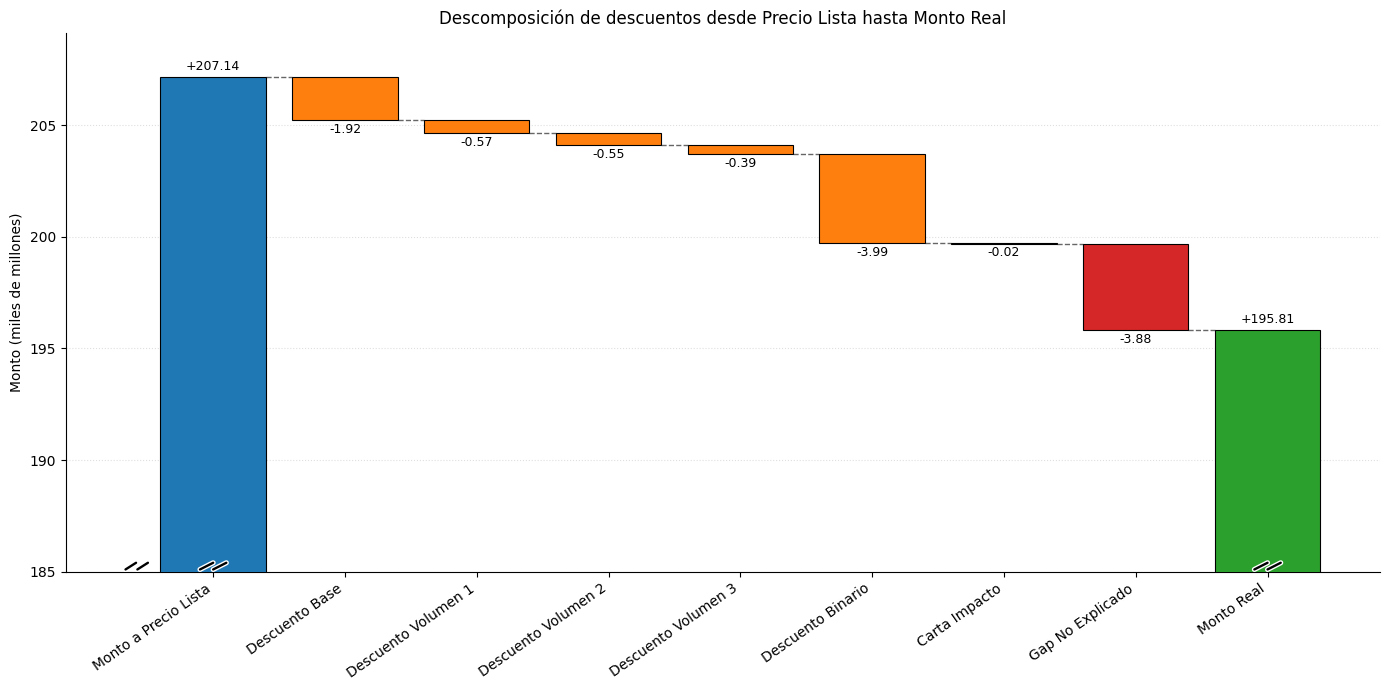

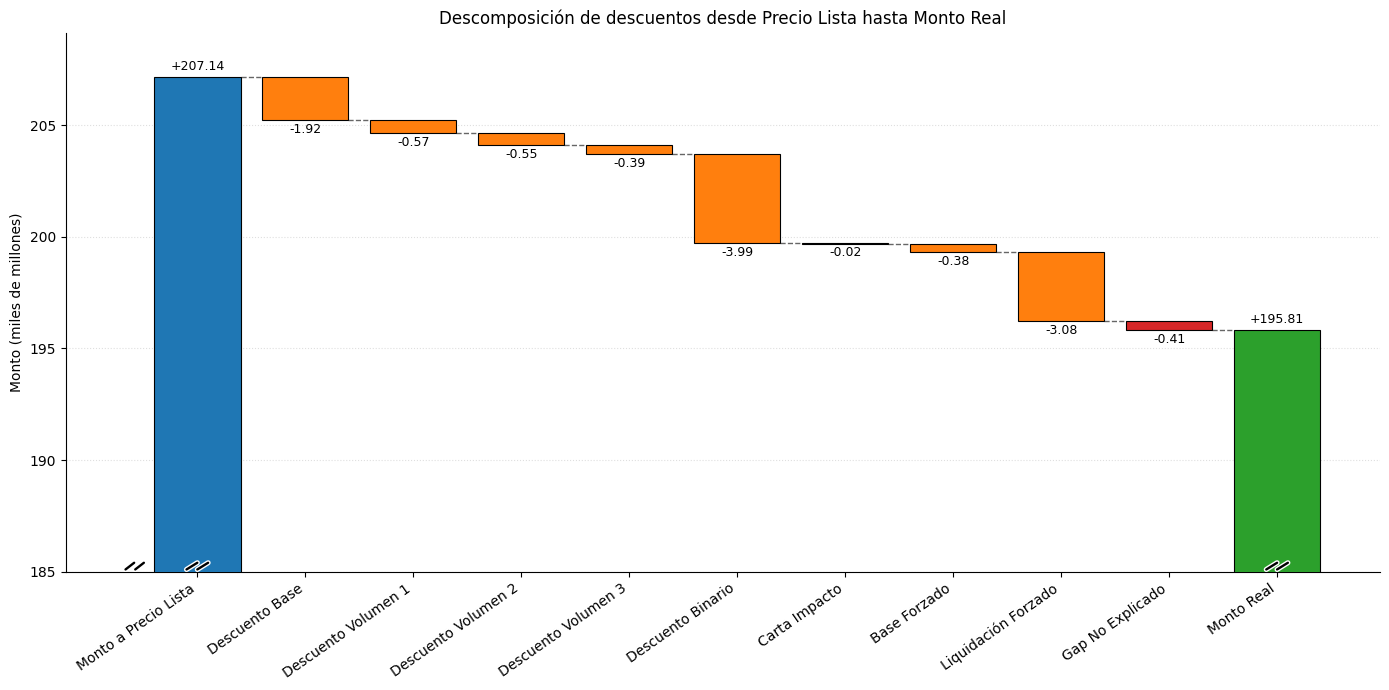


| % DSCTO OBSERVADO |         "COSTO" |
| ---------------------------------: | ------------: |
|                              -15.0 |  158 M |
|                              -10.0 |  85,9 M |
|                              -20.0 |  30,2 M |
|                              -17.0 |  25,1 M |
|                              -25.0 |  25,0 M |
|                              -18.0 |  18,7 M |
|                              -30.0 |  15,8 M |
|                              -19.0 |  10,5 M |
|                              -12.0 |  10,3 M |
|                               -9.0 |  10,2 M |
|                              -13.0 |  9,5 M |

